In [2]:
# ============================================================
# TASK 5 - SALES / TREND PREDICTION PROJECT
# Dataset Source: Kaggle
# Retail Sales Forecasting Data
# https://www.kaggle.com/datasets/svizor/retail-sales-forecasting-data
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

print("Task 5 - Sales / Trend Prediction")
print("Dataset Source: Kaggle - Retail Sales Forecasting Data")

Task 5 - Sales / Trend Prediction
Dataset Source: Kaggle - Retail Sales Forecasting Data


# Task 5 – Sales / Trend Prediction

### Dataset
**Retail Sales Forecasting Data**

The dataset was obtained from Kaggle and used to analyze sales trends over time, calculate moving averages, and predict future sales values.

**Dataset Source:**  
https://www.kaggle.com/datasets/svizor/retail-sales-forecasting-data

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Load only required columns
df = pd.read_csv(
    "sales.csv",
    usecols=["date", "quantity"]
)

print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
display(df.head())

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (129250, 2)

First 5 Rows:


,date,quantity
0,2023-08-04,1.000
1,2023-08-04,3.000
2,2023-08-04,0.822
3,2023-08-04,1.000
4,2023-08-04,7.000



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129250 entries, 0 to 129249
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   date      129250 non-null  object 
 1   quantity  129250 non-null  float64
dtypes: float64(1), object(1)
memory usage: 2.0+ MB

Missing Values:
date        0
quantity    0
dtype: int64


In [4]:
# Convert date column to datetime
df["date"] = pd.to_datetime(df["date"])

# Remove missing values
df = df.dropna(subset=["date", "quantity"])

# Calculate total sales quantity per day
daily_sales = df.groupby("date")["quantity"].sum().reset_index()

print("Daily Sales Data:")
display(daily_sales.head())

print("\nDaily Sales Shape:", daily_sales.shape)

Daily Sales Data:


,date,quantity
0,2023-08-04,33595.635
1,2023-08-07,28342.532
2,2023-08-08,26409.495
3,2023-08-09,26410.743
4,2023-08-15,27487.561



Daily Sales Shape: (28, 2)


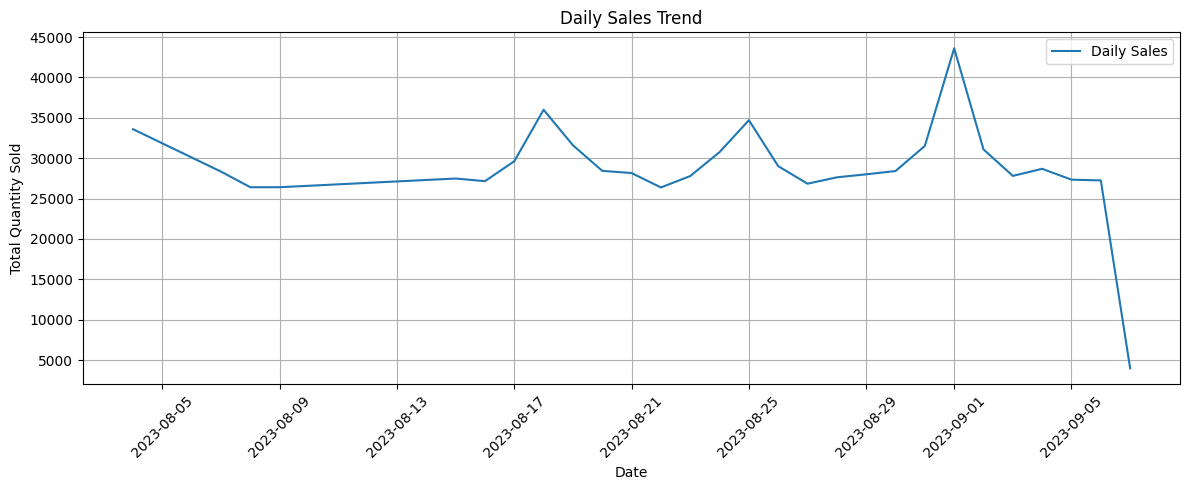

In [5]:
plt.figure(figsize=(12, 5))

plt.plot(
    daily_sales["date"],
    daily_sales["quantity"],
    label="Daily Sales"
)

plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Quantity Sold")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [6]:
# Calculate 7-day moving average
daily_sales["Moving_Average_7"] = (
    daily_sales["quantity"]
    .rolling(window=7)
    .mean()
)

print("Sales with 7-Day Moving Average:")
display(daily_sales.head(10))

Sales with 7-Day Moving Average:


,date,quantity,Moving_Average_7
0,2023-08-04,33595.635,NaN
1,2023-08-07,28342.532,NaN
2,2023-08-08,26409.495,NaN
3,2023-08-09,26410.743,NaN
4,2023-08-15,27487.561,NaN
5,2023-08-16,27162.974,NaN
6,2023-08-17,29622.597,28433.076714
7,2023-08-18,35999.506,28776.486857
8,2023-08-19,31605.962,29242.691143
9,2023-08-20,28438.437,29532.540000


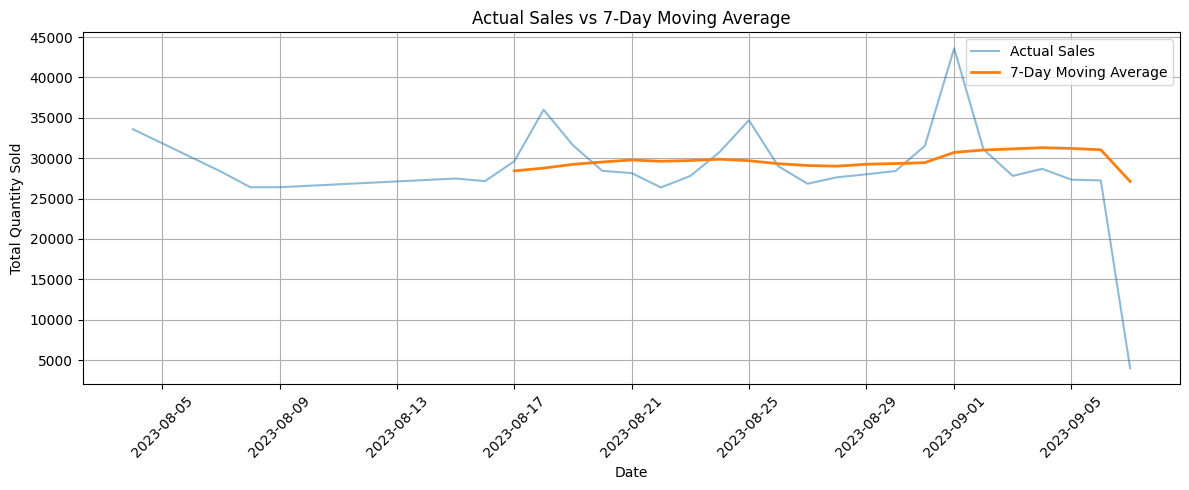

In [7]:
plt.figure(figsize=(12, 5))

plt.plot(
    daily_sales["date"],
    daily_sales["quantity"],
    label="Actual Sales",
    alpha=0.5
)

plt.plot(
    daily_sales["date"],
    daily_sales["Moving_Average_7"],
    label="7-Day Moving Average",
    linewidth=2
)

plt.title("Actual Sales vs 7-Day Moving Average")
plt.xlabel("Date")
plt.ylabel("Total Quantity Sold")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [8]:
# Predict the next 7 days using the latest 7-day average

last_7_days_average = daily_sales["quantity"].tail(7).mean()

last_date = daily_sales["date"].max()

future_dates = pd.date_range(
    start=last_date + pd.Timedelta(days=1),
    periods=7
)

predicted_sales = pd.DataFrame({
    "date": future_dates,
    "Predicted_Sales": [last_7_days_average] * 7
})

print("Next 7 Days Sales Prediction:")
display(predicted_sales)

print(f"\nAverage predicted sales per day: {last_7_days_average:.2f}")

Next 7 Days Sales Prediction:


,date,Predicted_Sales
0,2023-09-08,27114.471429
1,2023-09-09,27114.471429
2,2023-09-10,27114.471429
3,2023-09-11,27114.471429
4,2023-09-12,27114.471429
5,2023-09-13,27114.471429
6,2023-09-14,27114.471429



Average predicted sales per day: 27114.47


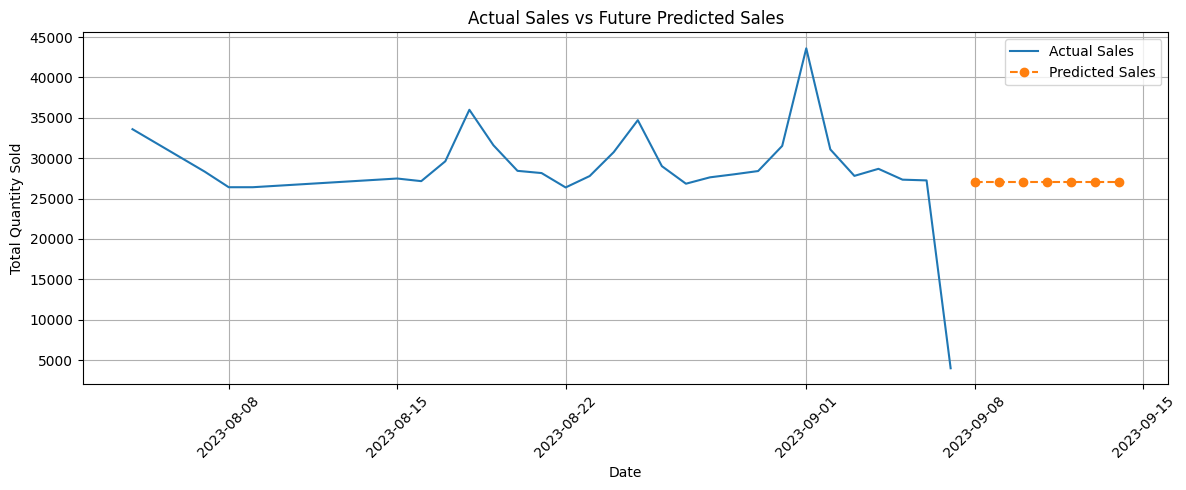

In [9]:
# Plot actual sales and future predicted sales

plt.figure(figsize=(12, 5))

# Actual sales
plt.plot(
    daily_sales["date"],
    daily_sales["quantity"],
    label="Actual Sales"
)

# Future predictions
plt.plot(
    predicted_sales["date"],
    predicted_sales["Predicted_Sales"],
    marker="o",
    linestyle="--",
    label="Predicted Sales"
)

plt.title("Actual Sales vs Future Predicted Sales")
plt.xlabel("Date")
plt.ylabel("Total Quantity Sold")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [10]:
print("Sales/Trend Prediction Summary")
print("--------------------------------")

print(f"Total days analyzed: {len(daily_sales)}")
print(f"Average daily sales: {daily_sales['quantity'].mean():.2f}")
print(f"Maximum daily sales: {daily_sales['quantity'].max():.2f}")
print(f"Minimum daily sales: {daily_sales['quantity'].min():.2f}")
print(f"7-day average sales: {last_7_days_average:.2f}")

print()
print("Key Observations:")
print("1. Daily sales show noticeable fluctuations over time.")
print("2. The 7-day moving average smooths short-term fluctuations.")
print("3. Some dates show significant sales spikes.")
print("4. The latest 7-day average was used to predict the next 7 days.")
print("5. The prediction provides a simple baseline for future sales.")

Sales/Trend Prediction Summary
--------------------------------
Total days analyzed: 28
Average daily sales: 28719.23
Maximum daily sales: 43609.31
Minimum daily sales: 3992.84
7-day average sales: 27114.47

Key Observations:
1. Daily sales show noticeable fluctuations over time.
2. The 7-day moving average smooths short-term fluctuations.
3. Some dates show significant sales spikes.
4. The latest 7-day average was used to predict the next 7 days.
5. The prediction provides a simple baseline for future sales.
